In [9]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [12]:
#importing libraries
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [13]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
#understand the dataset
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


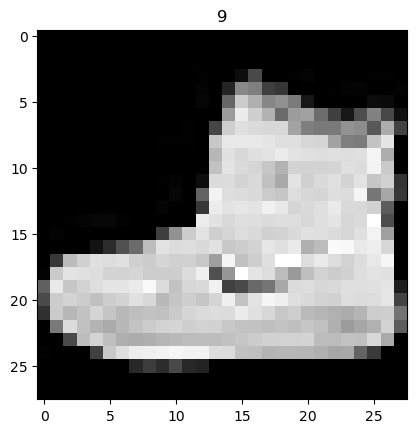

In [15]:
# means 60000 training images
# 10000 testing images 
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [16]:
# normalize data 
x_train = x_train / 255.0
x_test = x_test / 255.0

In [18]:
# Build Feed Forward Neural Network
# Input → Hidden Layer → Hidden Layer → Output

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model = Sequential([
    Input(shape=(28, 28)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8238 - loss: 0.4939
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8653 - loss: 0.3699
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8761 - loss: 0.3345
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8849 - loss: 0.3090
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.8900 - loss: 0.2927
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8958 - loss: 0.2795
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8994 - loss: 0.2687
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9040 - loss: 0.2556
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9062 - loss: 0.2476
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9100 - loss: 0.2390


In [23]:
# evalvate on test data 
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy =", test_acc)
print("Test Loss =", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8795 - loss: 0.3461
Test Accuracy = 0.8794999718666077
Test Loss = 0.34608709812164307


In [24]:
# predict images 
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
# get predicted class 
import numpy as np

predicted_label = np.argmax(predictions[0])

print("Predicted Label =", predicted_label)
print("Actual Label =", y_test[0])

Predicted Label = 9
Actual Label = 9


In [26]:
# show images 

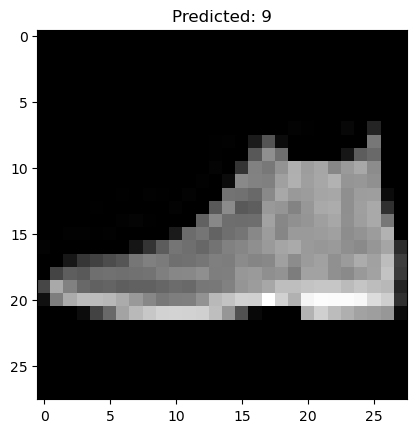

In [27]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.show()

In [28]:
# Convert Label Number to Fashion Name
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [29]:
# now print meaningfull output 
print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[y_test[0]])

Predicted: Ankle boot
Actual: Ankle boot


In [31]:
# plotting accuracy graph
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy =", test_acc)
print("Test Loss =", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8795 - loss: 0.3461
Test Accuracy = 0.8794999718666077
Test Loss = 0.34608709812164307


In [32]:
# predications 
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
import numpy as np

predicted_label = np.argmax(predictions[0])

print("Predicted Label =", predicted_label)
print("Actual Label =", y_test[0])

Predicted Label = 9
Actual Label = 9


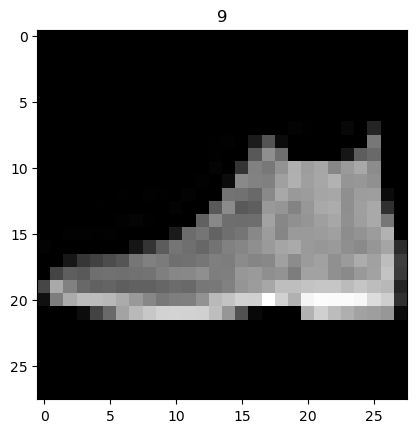

In [34]:
# show images 
import matplotlib.pyplot as plt

plt.imshow(x_test[0], cmap='gray')

plt.title(predicted_label)

plt.show()

In [35]:
# adding class name 
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [36]:
# now printing Prediction
print("Predicted:", class_names[predicted_label])

print("Actual:", class_names[y_test[0]])

Predicted: Ankle boot
Actual: Ankle boot


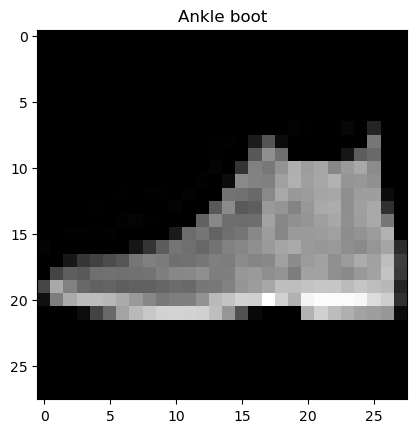

In [37]:
# now finally showing better image 
plt.imshow(x_test[0], cmap='gray')

plt.title(class_names[predicted_label])

plt.show()

In [38]:
# accuracy graph 
plt.plot(history.history['accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

NameError: name 'history' is not defined

In [39]:
history = model.fit(
    x_train,
    y_train,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9118 - loss: 0.2336
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9154 - loss: 0.2232
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9183 - loss: 0.2159
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9194 - loss: 0.2106
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9226 - loss: 0.2027
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9245 - loss: 0.1986
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9265 - loss: 0.1933
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9285 - loss: 0.1888
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9296 - loss: 0.1839
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9306 - loss: 0.1805


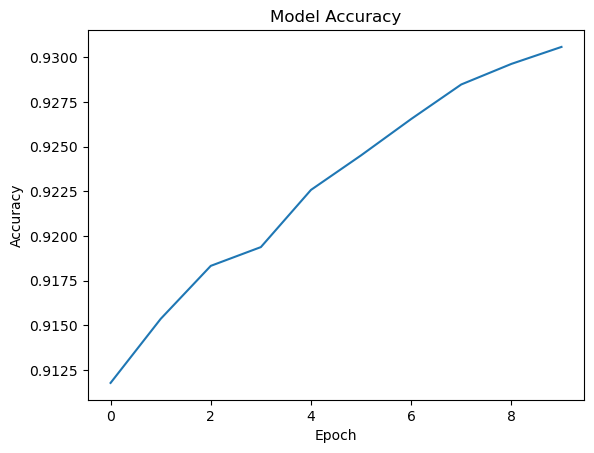

In [40]:
plt.plot(history.history['accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

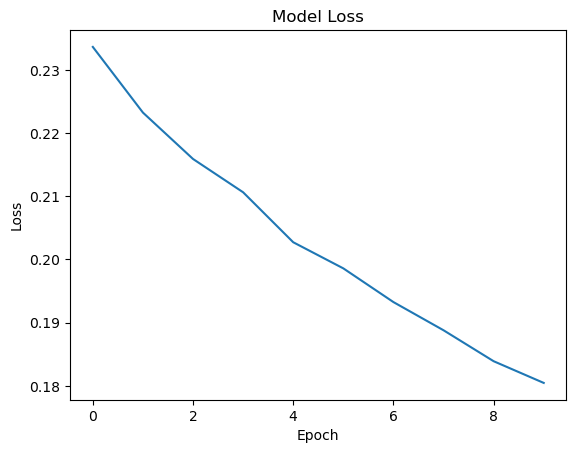

In [41]:
# loss graph
plt.plot(history.history['loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()